In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

from matplotlib.gridspec import GridSpec

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

#   Figure 2


In [28]:
###############################TO LOAD INFO#################################
data = np.load("Figure2.npz", allow_pickle=True)

Tvar = data["Tvar"]
Ttau_s = data["Ttau_s"]
Tbins_s = data["Tbins_s"]
Thisto_s = data["Thisto_s"]
Txfit_s = data["Txfit_s"]
Tyfit_s = data["Tyfit_s"]
Tnonzero_s= data["Tnonzero_s"] 
Tmean_s= data["Tmean_s"]
Tmean_t= data["Tmean_t"]
Tmean_diff= data["Tmean_diff"]

L1 = 256
L2 = 256

/tmp/ipykernel_455414/516339413.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


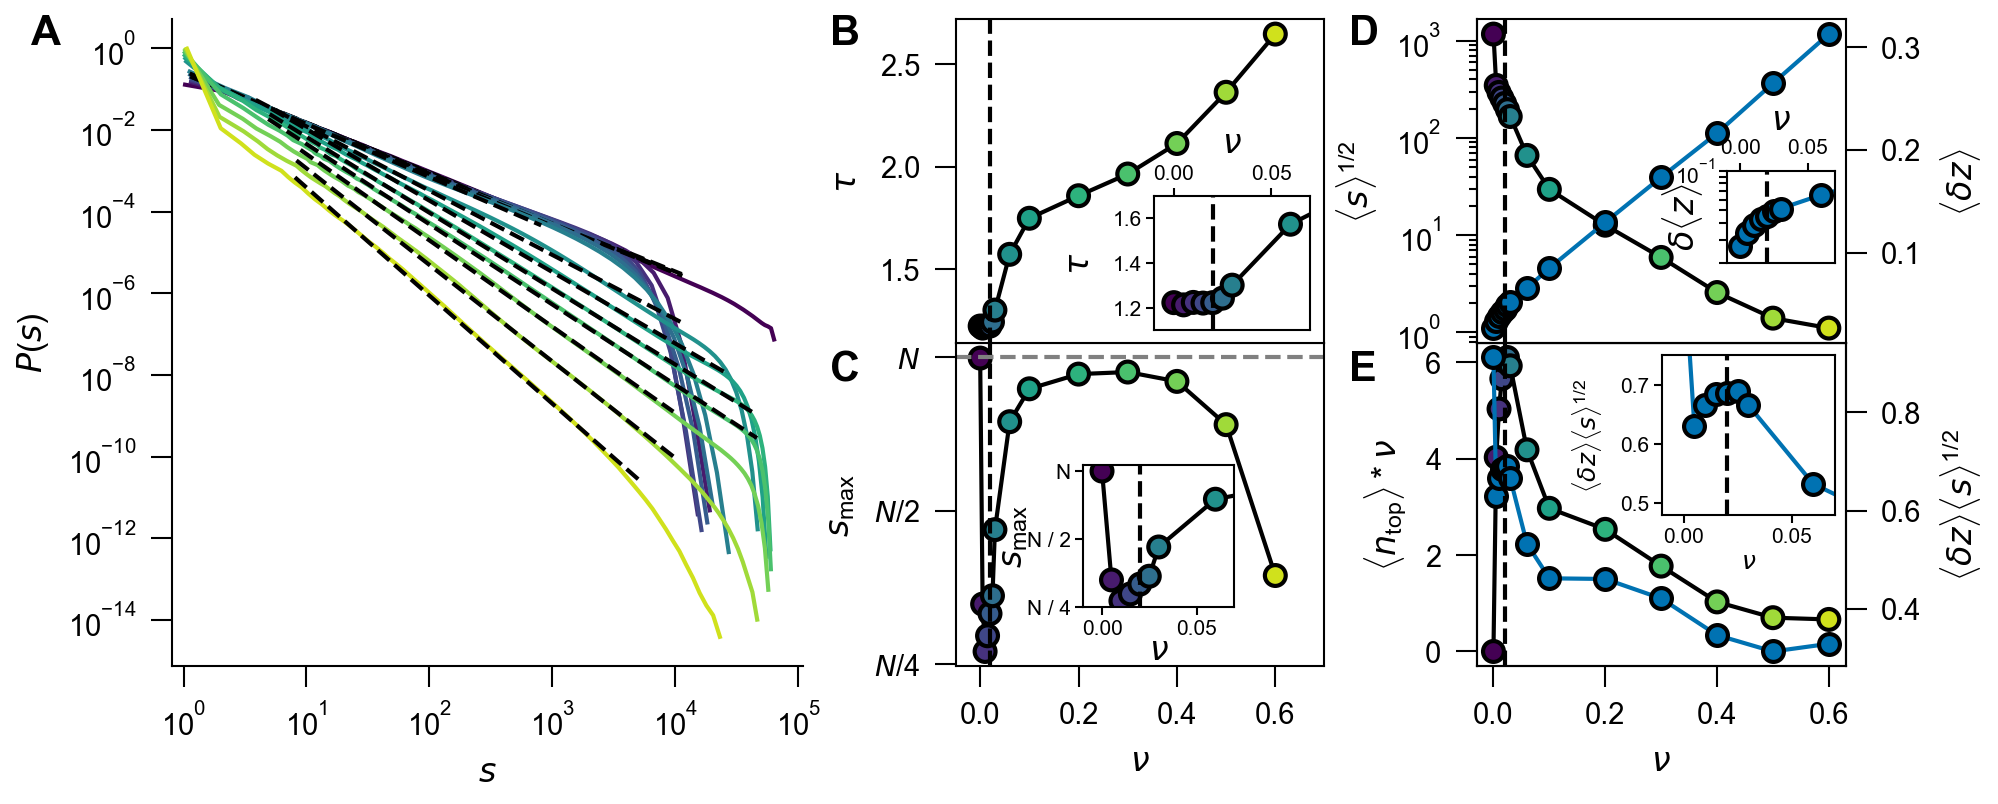

In [29]:
from matplotlib.ticker import FixedLocator, NullLocator
import matplotlib as mpl
NCURVES = len(Tvar)
with plt.style.context(spstyle.get_style('science-reviews')):
    # mpl.rcParams['mathtext.fontset'] = 'custom'
    # mpl.rcParams['mathtext.rm'] = 'Arial'
    # mpl.rcParams['mathtext.it'] = 'Arial:italic'
    # mpl.rcParams['mathtext.bf'] = 'Arial:bold'
    
    fig = plt.figure(figsize=(7.2, 2.8))
    gs = gridspec.GridSpec(2, 4, width_ratios=[1.5, 5, 5, 5], wspace = 0.5, hspace = 0)  # 2 lignes, 2 colonnes
    colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

    ################## P(s) ##################
    ax1 = fig.add_subplot(gs[:, :2])  # La figure 1 prend toute la largeur (2 colonnes)

    for i, (histo, bins, xfit, yfit) in enumerate(zip(Thisto_s, Tbins_s, Txfit_s, Tyfit_s)):
        ax1.plot(bins,histo, color = colors[i])
        ax1.plot(xfit, yfit, 'k--')

    ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
    ax1.set_xlim(0.8,1.1e5)
    ax1.set_xlabel(r'$s$')
    ax1.set_ylabel(r'$P(s)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    

    
    ################## Smax ##################
    ax2 = fig.add_subplot(gs[1, 2])
    ax2.scatter(Tvar, Tnonzero_s, c=colors, marker='o', zorder=2)  # s contrôle la taille des marqueurs
    ax2.plot(Tvar, Tnonzero_s, '-', c = 'k', zorder=1)  # s contrôle la taille des marqueurs
    ax2.axvline(Tvar[4], ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
    ax2.axhline(L1 * L2, c = "grey", ls = '--')
    ax2.xaxis.set_visible(True)
    ax2.set_xlabel(r'$\nu$')
    ax2.set_ylabel(r'$s_\mathrm{max}$')
    ax2.set_yscale('log')
    
    N = L1*L2
    yticks = [N, N/2, N/4]
    ax2.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax2.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax2.set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])
    ax2.set_xlim(-0.05,0.7) 
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)

    ax22 = fig.add_axes([0.547, 0.18, 0.07, 0.17])
    ax22.scatter(Tvar, Tnonzero_s, c=colors, marker='o', zorder=2)  # s contrôle la taille des marqueurs
    ax22.plot(Tvar, Tnonzero_s, '-', c = 'k', zorder=1)
    ax22.axvline(Tvar[4], ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
    ax22.set_xlim(-0.01,0.07)
    # para_fig(ax22, r'$\nu$', r'$s_{max}$',type = 'semilog', labelsize = medium_debug, tickssize= small_debug/1.5, width_M = 1, length_M = 5)
    ax22.set_xlabel(r'$\nu$')
    ax22.set_ylabel(r'$s_\mathrm{max}$')
    ax22.set_yscale('log')
    ax22.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax22.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax22.set_yticklabels(['N', 'N / 2', 'N / 4'])
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    ax22.tick_params(labelsize = 5, length = 2, pad = 1)
    ax22.xaxis.set_label_coords(0.5, -0.2) 
    ax22.yaxis.set_label_coords(-0.35, 0.5) 

    ################## Avg_dissipated energy ##################
    ax3 = fig.add_subplot(gs[1, 3])  # La figure 1 prend toute la largeur (2 colonnes)
    ax3.scatter(Tvar, Tmean_t * Tvar, c=colors, marker='o', zorder=2)
    ax3.plot(Tvar, Tmean_t * Tvar, c = 'k', zorder = 1)

    ax32 = ax3.twinx()
    ax32.plot(Tvar, Tmean_diff*Tmean_s**(1/2), marker = 'o', c ='#0072b2')
    ax32.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    
    ax33 = fig.add_axes([0.815, 0.29, 0.08, 0.19])
    ax33.plot(Tvar, Tmean_diff*Tmean_s**(1/2), marker = 'o', c = '#0072b2')
    ax33.axvline(Tvar[4], linestyle = '--', c = 'k', zorder = 2)
    
    ax3.set_xlabel(r'$\nu$')
    ax3.set_ylabel(r'$\langle n_\mathrm{top} \rangle * \nu$')
    ax32.set_xlabel(r'$\nu$')
    ax32.set_ylabel(r'$ \langle \delta z\rangle \langle s \rangle^{1/2}$')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    ax32.spines['top'].set_visible(True)
    ax32.spines['right'].set_visible(True)
    # ax32.set_ylim(-0.02, 0.87)
    
    ax33.set_xlabel(r'$\nu$', fontsize = 6)
    ax33.set_ylabel(r'$ \langle \delta z \rangle \langle s \rangle^{1/2}$', fontsize = 6)
    ax33.set_xlim(-0.01,0.07)
    ax33.set_ylim(0.48, 0.75)
    
    ax33.xaxis.labelpad = 1
    ax33.spines['top'].set_visible(True)
    ax33.spines['right'].set_visible(True)
    ax33.tick_params(labelsize = 5, length = 2, pad = 1)

    ################## Exposant ##################
    ax4 = fig.add_subplot(gs[0, 2])  # La figure 1 prend toute la largeur (2 colonnes)
    ax4.scatter(Tvar, -Ttau_s, c = colors, zorder=2, marker = 'o')
    ax4.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)       
    ax4.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]))
    ax4.set_xlim(-0.05,0.7) 
    ax4.xaxis.set_visible(False)
    ax4.set_xlabel(r'$\nu$')
    ax4.set_ylabel(r'$\tau$')
    ax4.spines['top'].set_visible(True)
    ax4.spines['right'].set_visible(True)
    


    ax42 = fig.add_axes([0.58, 0.51, 0.072, 0.16])
    ax42.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)
    ax42.scatter(Tvar, -Ttau_s, c = colors, zorder=2, marker = 'o')
    ax42.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]))
    ax42.set_xlim(-0.01,0.07)
    ax42.set_ylim(1.1,1.7)

    ax42.xaxis.set_label_coords(-0.5, 1.5) 
    ax42.xaxis.set_ticks_position('top')
    ax42.set_xlabel(r'$\nu$')
    ax42.set_ylabel(r'$\tau$')
    ax42.spines['top'].set_visible(True)
    ax42.spines['right'].set_visible(True)
    ax42.tick_params(labelsize = 5, length = 2, pad = 1)
    

    ################## <s> <dz> ##################
    ax5 = fig.add_subplot(gs[0, 3])

    ax5.scatter(Tvar, Tmean_s, c = colors, zorder=2, marker = 'o')
    ax5.plot(Tvar, Tmean_s, c = 'k', zorder=1)

    ax52 = ax5.twinx()
    ax52.plot(Tvar, Tmean_diff, marker = 'o', c = '#0072b2')
    ax52.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax53 = fig.add_axes([0.845, 0.59, 0.05, 0.11])
    ax53.plot(Tvar, Tmean_diff, marker = 'o', c = '#0072b2')
    ax53.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax5.set_xlabel(r'$\nu$')
    ax5.set_ylabel(r'$\langle s \rangle^{1/2}$')
    ax5.set_yscale('log')
    ax5.xaxis.set_visible(False)
    ax52.set_xlabel('')
    ax52.set_ylabel(r'$\langle  \delta z \rangle$')
    ax52.spines['top'].set_visible(True)
    ax52.spines['right'].set_visible(True)
    ax53.set_xlabel(r'$\nu$')
    ax53.set_ylabel(r'$\delta \langle  z \rangle$')
    ax53.set_yscale('log')
    ax53.set_xlim(-0.01,0.07)
    ax53.set_ylim(2e-2,1e-1)
    ax53.yaxis.set_label_coords(-0.2, 0.5) 
    ax53.xaxis.set_label_coords(0.5, 1.7) 
    ax53.tick_params(labelsize = 5, length = 2, pad = 1)
    ax53.yaxis.set_minor_formatter(plt.NullFormatter())
    ax53.xaxis.set_ticks_position('top')
    ax53.spines['top'].set_visible(True)
    ax53.spines['right'].set_visible(True)
    

    fig.text(0.06, 0.85, "A", fontsize=10, fontweight="bold") 
    fig.text(0.43, 0.85, "B", fontsize=10, fontweight="bold")  
    fig.text(0.67, 0.85, "D", fontsize=10, fontweight="bold") 
    fig.text(0.43, 0.45, "C", fontsize=10, fontweight="bold")
    fig.text(0.67, 0.45, "E", fontsize=10, fontweight="bold")
    plt.savefig("Fig2_science.pdf",  bbox_inches='tight', dpi = 300)
    plt.show()


#   Clustering

In [30]:
data3_5 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_5.npz")
data3_4 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_4.npz")
data3_7 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_7.npz")

In [31]:
print(data3_5.files)
print(data3_4.files)
print(data3_7.files)

['nu', 't_nu0', 'p_t_nu0', 'xfit_nu0', 'yfit_nu0', 't_nu0_005', 'p_t_nu0_005', 'xfit_nu0_005', 'yfit_nu0_005', 't_nu0_01', 'p_t_nu0_01', 'xfit_nu0_01', 'yfit_nu0_01', 't_nu0_015', 'p_t_nu0_015', 'xfit_nu0_015', 'yfit_nu0_015', 't_nu0_02', 'p_t_nu0_02', 'xfit_nu0_02', 'yfit_nu0_02', 't_nu0_025', 'p_t_nu0_025', 'xfit_nu0_025', 'yfit_nu0_025', 't_nu0_03', 'p_t_nu0_03', 'xfit_nu0_03', 'yfit_nu0_03', 't_nu0_06', 'p_t_nu0_06', 'xfit_nu0_06', 'yfit_nu0_06', 't_nu0_1', 'p_t_nu0_1', 'xfit_nu0_1', 'yfit_nu0_1', 't_nu0_2', 'p_t_nu0_2', 'xfit_nu0_2', 'yfit_nu0_2', 't_nu0_3', 'p_t_nu0_3', 'xfit_nu0_3', 'yfit_nu0_3', 't_nu0_4', 'p_t_nu0_4', 'xfit_nu0_4', 'yfit_nu0_4', 't_nu0_5', 'p_t_nu0_5', 'xfit_nu0_5', 'yfit_nu0_5', 't_nu0_6', 'p_t_nu0_6', 'xfit_nu0_6', 'yfit_nu0_6', 'gamma', 'yperr', 't_dearcangelis', 'p_t_dearcangelis', 'L', 'system1', 'system2', 'system3', 'system4']
['system', 'L', 'last_epicenter_x_y', 'next_epicenter_x_y', 'side_view_before', 'side_view_after']
['L', 'system1', 'epicenter1'

In [32]:
Tnu = data3_5["nu"]

Tp_t = [None] * len(Tnu)
Tt = [None] * len(Tnu)
Txfit = [None] * len(Tnu)
Tyfit = [None] * len(Tnu)



for i, nu in enumerate(Tnu):
    nu_str = str(nu).replace('.', '_')
    if i == 0: nu_str = "0"

    Tp_t[i] = data3_5[f"p_t_nu{nu_str}"]
    Tt[i] = data3_5[f"t_nu{nu_str}"]
    Txfit[i] = data3_5[f"xfit_nu{nu_str}"]
    Tyfit[i] = data3_5[f"yfit_nu{nu_str}"]
    

Tgamma = data3_5["gamma"]

L = data3_4["L"]
sys_snap = data3_4["system"].reshape(L,L)
last_epi = data3_4["last_epicenter_x_y"]
next_epi = data3_4["next_epicenter_x_y"]
sideview_before = data3_4["side_view_before"]
sideview_after = data3_4["side_view_after"]

snap_cons = data3_7["system1"].reshape(L,L)
epi_cons =  np.unravel_index(data3_7["epicenter1"], (L,L))
snap_diss = data3_7["system3"].reshape(L,L)
epi_diss = np.unravel_index(data3_7["epicenter3"],(L,L))

In [33]:
nrows = len(epi_cons[0])
colors = [plt.cm.get_cmap('plasma')(i/nrows) for i in range(nrows)]

nrows_tp = len(Tnu)
colors_pt = [plt.cm.get_cmap('viridis')(i/nrows_tp) for i in range(nrows_tp)]

/tmp/ipykernel_455414/3795462054.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('plasma')(i/nrows) for i in range(nrows)]
/tmp/ipykernel_455414/3795462054.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_pt = [plt.cm.get_cmap('viridis')(i/nrows_tp) for i in range(nrows_tp)]


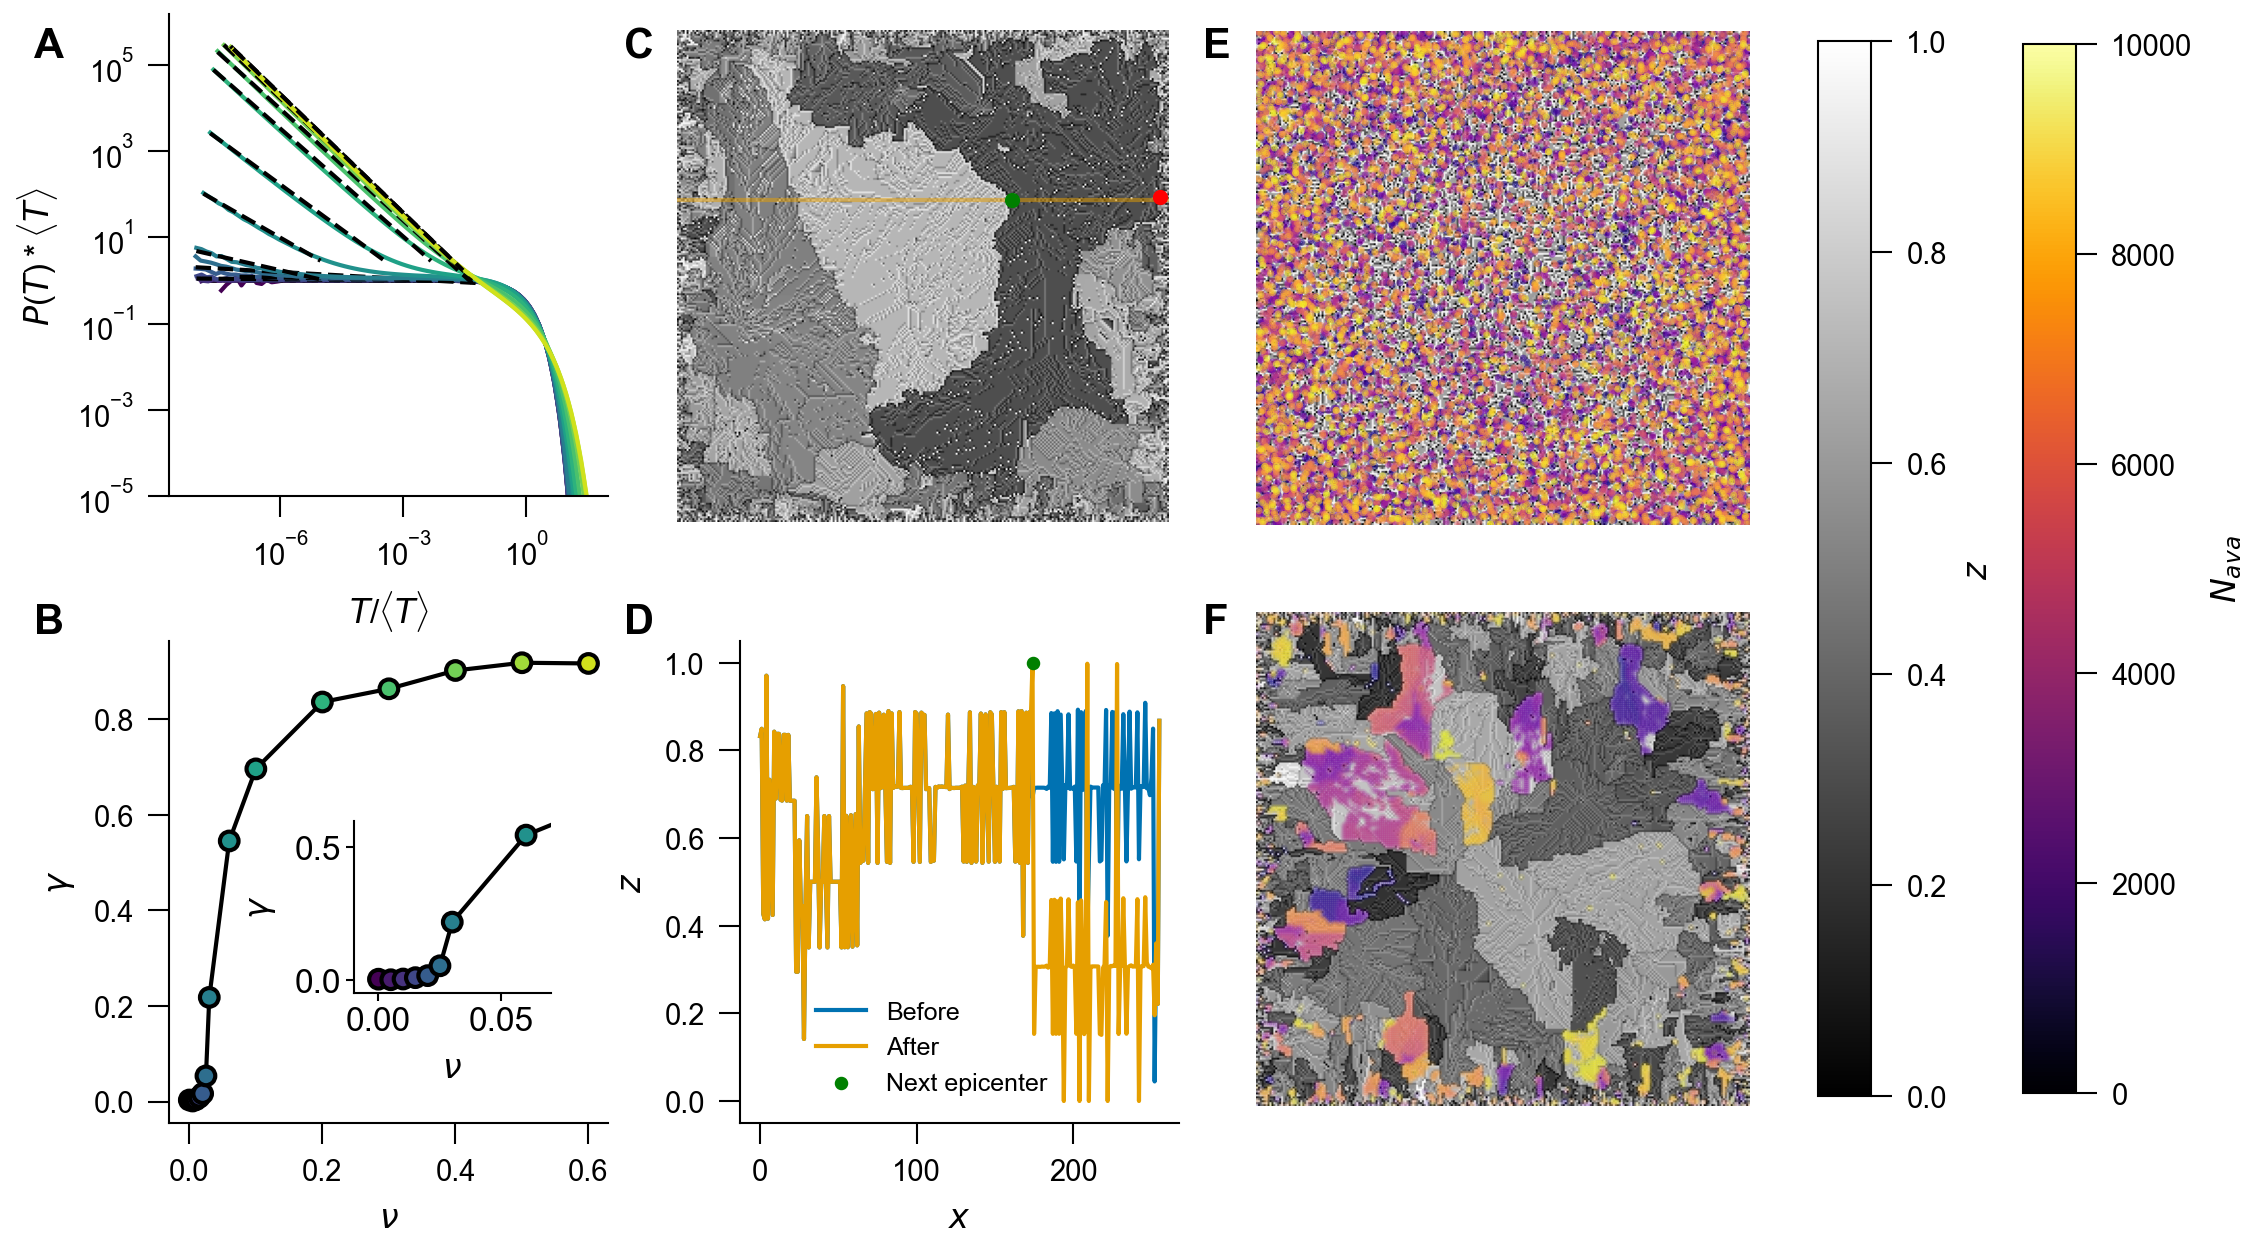

In [34]:
with plt.style.context(spstyle.get_style('science-reviews')):
    fig = plt.figure(figsize=(8.2, 4.8))
    
    gs1 = gridspec.GridSpec(2, 3, wspace = 0.3, hspace = 0.3)
    gs2 = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.1)
    gs3 = gridspec.GridSpec(2, 3, width_ratios=[0.27,0.4,0.33], height_ratios=[0.52,0.48], wspace = 0.43, hspace = 0.2)
    
    ax1 = fig.add_subplot(gs1[0, 0])
    ax2 = fig.add_subplot(gs1[1, 0])
    ax3 = fig.add_subplot(gs1[1, 1])
    ax4 = fig.add_subplot(gs3[0, 1])
    ax5 = fig.add_subplot(gs2[0, 2])
    ax6 = fig.add_subplot(gs2[1, 2])
    
    ax32 = fig.add_axes([0.2, 0.2, 0.08, 0.12])
    
    for i in range(len(Tnu)):
        ax1.plot(Tt[i],Tp_t[i], c = colors_pt[i])
        ax1.plot(Txfit[i],Tyfit[i], c ='k', ls = '--')
    
    im = ax4.imshow(sys_snap, cmap = 'gray', vmin = 0, vmax = 1)
    ax4.axhline(next_epi[1], c = color_list[2], alpha = 0.5)
    ax4.scatter(last_epi[0], last_epi[1], color = 'r', s = 7, zorder = 5)
    ax4.scatter(next_epi[0], next_epi[1], color = 'g', s = 7, zorder = 5)

    
    ax5.imshow(snap_cons, cmap ='binary', vmin = 0, vmax = 1)
    ax5.scatter(epi_cons[1], epi_cons[0], color = colors, s = 0.5, alpha = 0.5)
    
    ax2.scatter(Tnu, -Tgamma, c = colors_pt, s = 20, zorder = 10)
    ax2.plot(Tnu, -Tgamma, ls = '-', c ='k')
    ax32.scatter(Tnu, -Tgamma, c = colors_pt, s = 20, zorder = 10)
    ax32.plot(Tnu, -Tgamma, ls = '-', c ='k')
    
    ax32.tick_params(labelsize = 8, length = 2, pad = 1)
    ax3.plot(sideview_before, c = color_list[0], label = "Before")
    ax3.plot(sideview_after, c = color_list[2], label = "After")
    ax3.scatter(next_epi[0], sideview_after[next_epi[0]], color = 'g', s = 5, zorder = 2, label = "Next epicenter")
    
    ax6.imshow(snap_diss, cmap ='binary', vmin = 0, vmax = 1)
    ax6.scatter(epi_diss[1], epi_diss[0], color = colors, s = 0.5, alpha = 0.1)
    
    norm = plt.Normalize(0, nrows)
    sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
    sm.set_array([])
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    cbar = fig.colorbar(sm, ax=axes, location='right',
                        fraction=0.0275, aspect=20, pad=0.08)

    cbar2 = fig.colorbar(im, ax=axes, location='right',
                        fraction=0.031, aspect=20, pad=0.04)
    cbar.set_label(r"$N_{ava}$")
    cbar2.set_label(r"$z$")
    
    
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlim(2e-9, 1e2)
    ax1.set_ylim(1e-5, 1.5e6)
    ax1.set_xlabel(r"$T / \langle T \rangle$")
    ax1.set_ylabel(r"$P(T)*\langle T \rangle$")
    ax4.set_axis_off()
    ax5.set_axis_off()
    ax2.set_xlabel(r"$\nu$")
    ax2.set_ylabel(r"$\gamma$")
    ax32.set_xlabel(r"$\nu$")
    ax32.set_ylabel(r"$\gamma$")
    ax32.set_xlim(-0.01,0.07)
    ax32.set_ylim(-0.05,0.6)
    ax3.set_xlabel(r"$x$")
    ax3.set_ylabel(r"$z$")
    ax3.legend(bbox_to_anchor = (0.75,0.3))
    ax6.set_axis_off()
    
    fig.text(0.07, 0.85, "A", fontsize=10, fontweight="bold") 
    fig.text(0.31, 0.85, "C", fontsize=10, fontweight="bold")
    fig.text(0.545, 0.85, "E", fontsize=10, fontweight="bold")
    fig.text(0.07, 0.45, "B", fontsize=10, fontweight="bold") 
    fig.text(0.31, 0.45, "D", fontsize=10, fontweight="bold")
    fig.text(0.545, 0.45, "F", fontsize=10, fontweight="bold")
    
    
    plt.savefig("Fig3_science.pdf", dpi = 300)
    plt.show()

#   Democratic

In [35]:
data = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_9.npz")
print(data.files)


['L', 's_nu0_OFC', 'p_s_nu0_OFC', 's_nu0', 'p_s_nu0', 's_nu0_02', 'p_s_nu0_02', 's_nu0_04', 'p_s_nu0_04', 's_nu0_06', 'p_s_nu0_06', 's_nu0_1', 'p_s_nu0_1', 'system1', 'system2']


/tmp/ipykernel_455414/1668420195.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


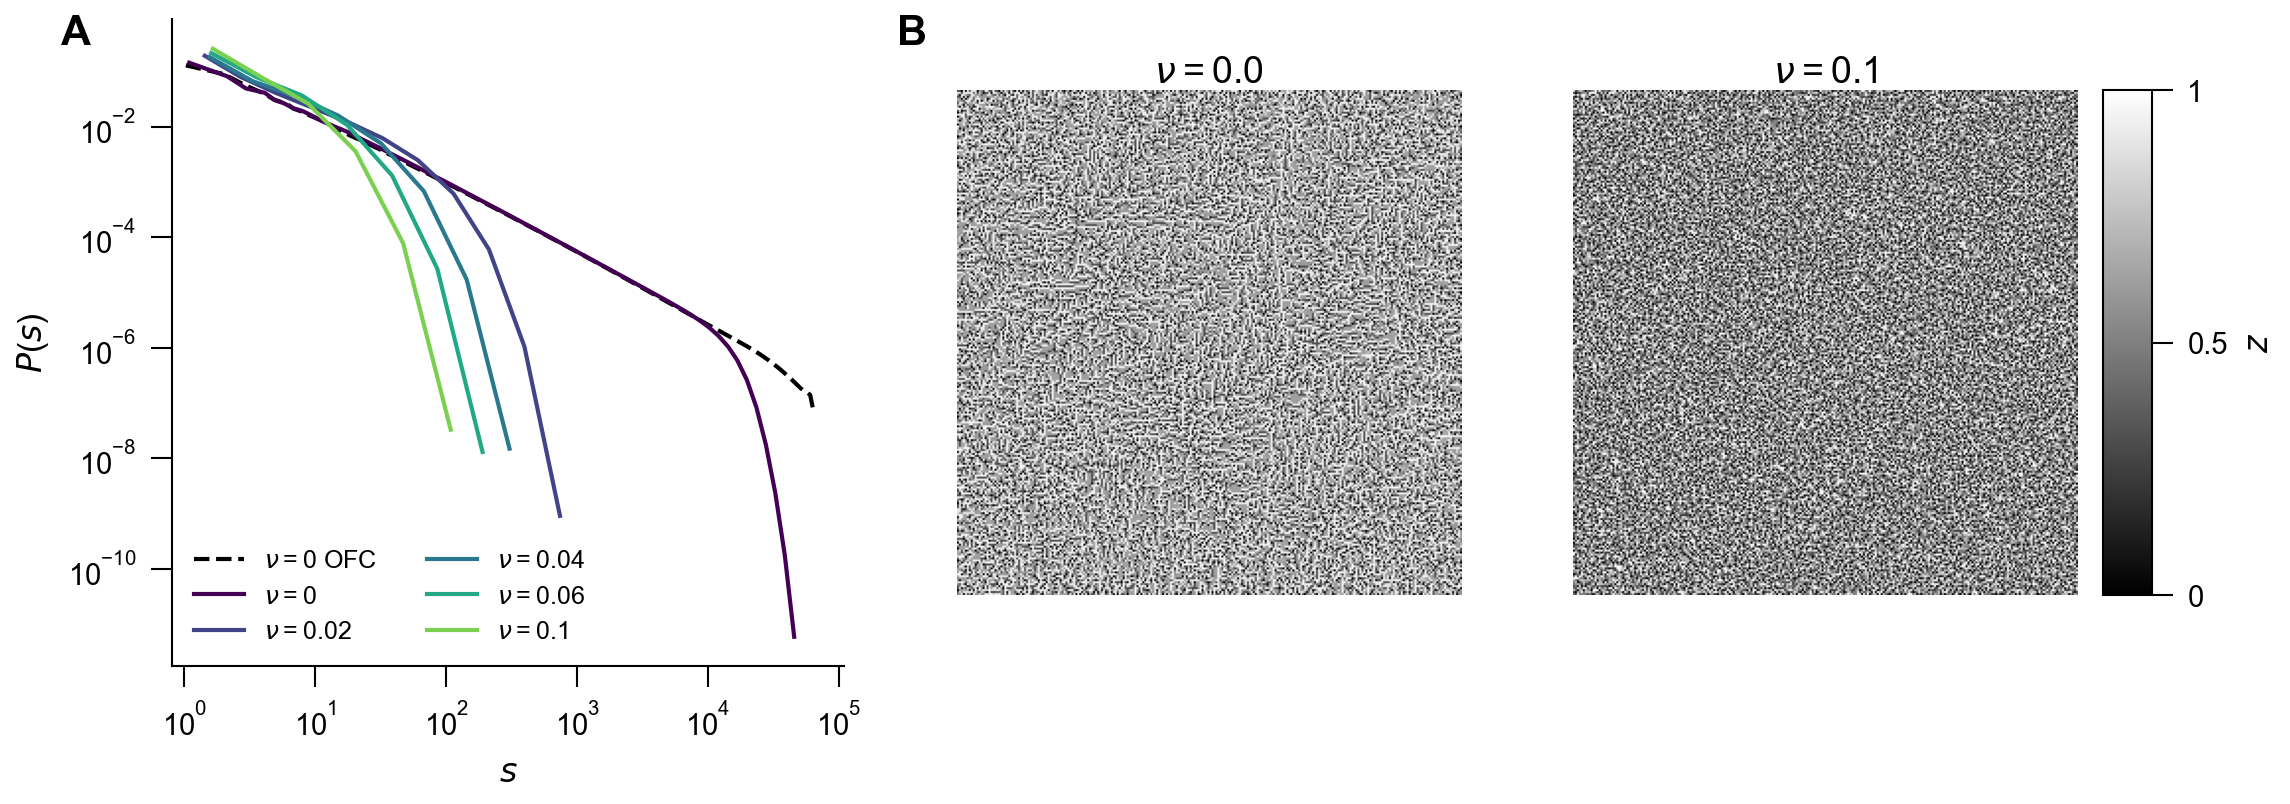

In [36]:
Tnu = [0, 0.02, 0.04, 0.06, 0.1]
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
s_OFC = data["s_nu0_OFC"] 
ps_OFC = data["p_s_nu0_OFC"]
L = data["L"]

sys1 = data["system1"]
sys2 = data["system2"]

with plt.style.context(spstyle.get_style('science-reviews')):
    fig = plt.figure(figsize=(8.2, 2.8))
    gs1 = GridSpec(1, 3, wspace = 0.2, width_ratios=[0.4, 0.3, 0.3])

    ax1 = fig.add_subplot(gs1[0])
    ax2 = fig.add_subplot(gs1[1]) 
    ax3 = fig.add_subplot(gs1[2]) 

    ax1.plot(s_OFC, ps_OFC, label = r"$\nu = 0$ OFC", c = 'k', ls = '--')
    for i, nu in enumerate(Tnu):
        nu_str = str(nu).replace('.', '_')
        if i == 0: nu_str = "0"
        
        s = data[f"s_nu{nu_str}"]
        ps = data[f"p_s_nu{nu_str}"]
        
        ax1.plot(s, ps, label = r"$\nu = {}$".format(nu), c = colors[i])
    
    
    
    ax2.imshow(sys1.reshape(L,L), cmap = "binary")
    ax3.imshow(sys2.reshape(L,L), cmap = "binary")
    pos = ax3.get_position()
    
    
    
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])  # [x0, y0, width, height]
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 0.5, 1.0])
    cbar.set_label(r'$z$')
    cbar.set_ticks([0,0.5,1.0])
    cbar.set_ticklabels(['0', '0.5', '1'])
    
    ax1.set_xlabel(r'$s$')
    ax1.set_ylabel(r'$P(s)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(0.8,1.1e5)
    ax1.set_xticks([1, 1e1, 1e2, 1e3, 1e4, 1e5])
    ax1.set_yticks([1e-2, 1e-4, 1e-6, 1e-8, 1e-10])
    ax1.legend(ncol = 2, loc = "lower left")

    
    ax2.set_axis_off()
    ax2.set_title(r"$\nu = 0.0$", pad = 2)
    ax3.set_axis_off()
    ax3.set_title(r"$\nu = 0.1$", pad = 2)
    
    fig.text(0.08, 0.85, "A", fontsize=10, fontweight="bold") 
    fig.text(0.42, 0.85, "B", fontsize=10, fontweight="bold")  
    
    plt.savefig("Fig4_science.pdf", dpi = 300)
    plt.show()
     
    
    

#   Figure 5

In [11]:
def count_lines_gz_safe(filename, csize = 1000):
    count = 0
    chunk_size = csize 
    try:
        with gzip.open(filename, 'rb') as f:
            leftover = b''
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                lines = (leftover + chunk).split(b'\n')
                leftover = lines.pop()  # dernière ligne peut être tronquée
                count += len(lines)
            if leftover:
                count += 1  # compte la dernière ligne même si tronquée
    except EOFError:
        # fichier tronqué, on arrête là et on retourne le compte
        pass
    return count

def process_parallel_load(foldernb, nb = [1,2,3,4,5,6,7,8,9], chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    # logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    # histo_s = np.zeros(len(logbins_s)-1)
    bins_s = np.arange(0, L**2)
    histo_s = np.zeros(len(bins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    for i in nb:
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                # histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
                histo_s += np.histogram(chunk.iloc[:, 0], bins = bins_s)[0]
                histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
                
                nblines += len(chunk)
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s= int(float(line.strip().split()[cols[0]]))

                    # id = np.searchsorted(logbins_s, s, side='right') -1
                    # histo_s[id] += 1
                    histo_s[s] +=1
                    
                    id = np.searchsorted(logbins_a, 1/s, side='left') - 1
                    histo_a[id] += 1
                    
                    if i >= limdata:
                        break
        
    logbins_s, loghisto_s = new_logbins(histo_s, nbins)
    
    # log_histo, log_bins = loghisto(histo_s)
    # norm_histo_s = loghisto_s/((np.diff(logbins_s)) * np.sum(loghisto_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    # return logbins_s, norm_histo_s, logbins_a, norm_histo_a
    return logbins_s, loghisto_s, logbins_a, norm_histo_a

def floor_sig(x, n=1): #Pour récupére le floor de la valeur
    p = int(np.floor(np.log10(abs(x))))
    fact = 10 ** (p - n + 1)
    return int(np.floor(x / fact) * fact)

def count_lines(Tfolder_nb, nbfolder):
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        min = 1e10
        print(nb)
        for i in range(1,nbfolder+1):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = count_lines_gz_safe(file)
            print (nbl)
            if nbl < min:
                min = nbl
        print(min)
        
def full_analysis(Tfolder_nb, nbins = 50, cols = [12], nbfolder = [1,2,3,4,5,6,7,8,9]): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in nbfolder:
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        print(min)
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a
    
def gamma_th():

    fnb = np.arange(1,15)
    folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
    """ folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
    Tvar = [read_parameters(folder)[2] for folder in folderpath]

    results = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)
    Thisto_s, Tbins_s, _, _, _ = zip(*results)

    Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
    Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
    _, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)
    
    gamma = (-Ttau_s) - (-Ttau_s[0]) - 1
    
    return Tvar, gamma
    

def log_exppowlaw(x, a, b, c):
    return np.log(a)-b*np.log(x)-x/c


def powercutoff_fit(x, a, b, c, d):
    return a * x **(-b) * np.exp(-(x / c) ** d)

In [12]:
Tfolder_nb = [77,78,79,80,81,83, 82]
Tbin_s1, Thisto_s1, Tbin_a1, Thisto_a1 = full_analysis(Tfolder_nb, nbfolder = [2,3,4,5,6,7,8,9], nbins = 50, cols =[12])

36000
360000
390000
380000
360000
290000
340000


In [13]:
Tnu_th, Tgamma_th = gamma_th()

0.96545763582405
0.9971726928826957
0.9940950079772213
0.9970879131270517
0.9967105205796035
0.9906659255469019
0.9877020531728582
0.9272213838997168
0.9122521887346848
0.9705872766834267
0.9174095398449836
0.9057453446744788
0.8991641398725068
0.8933054895985362


/tmp/ipykernel_455414/1317841639.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


0.9996666666666667
0.0
0.0
0.0
0.0
0.0
0.9988888888888889
0.998
0.996
0.987
0.9813333333333333
0.9836842105263158


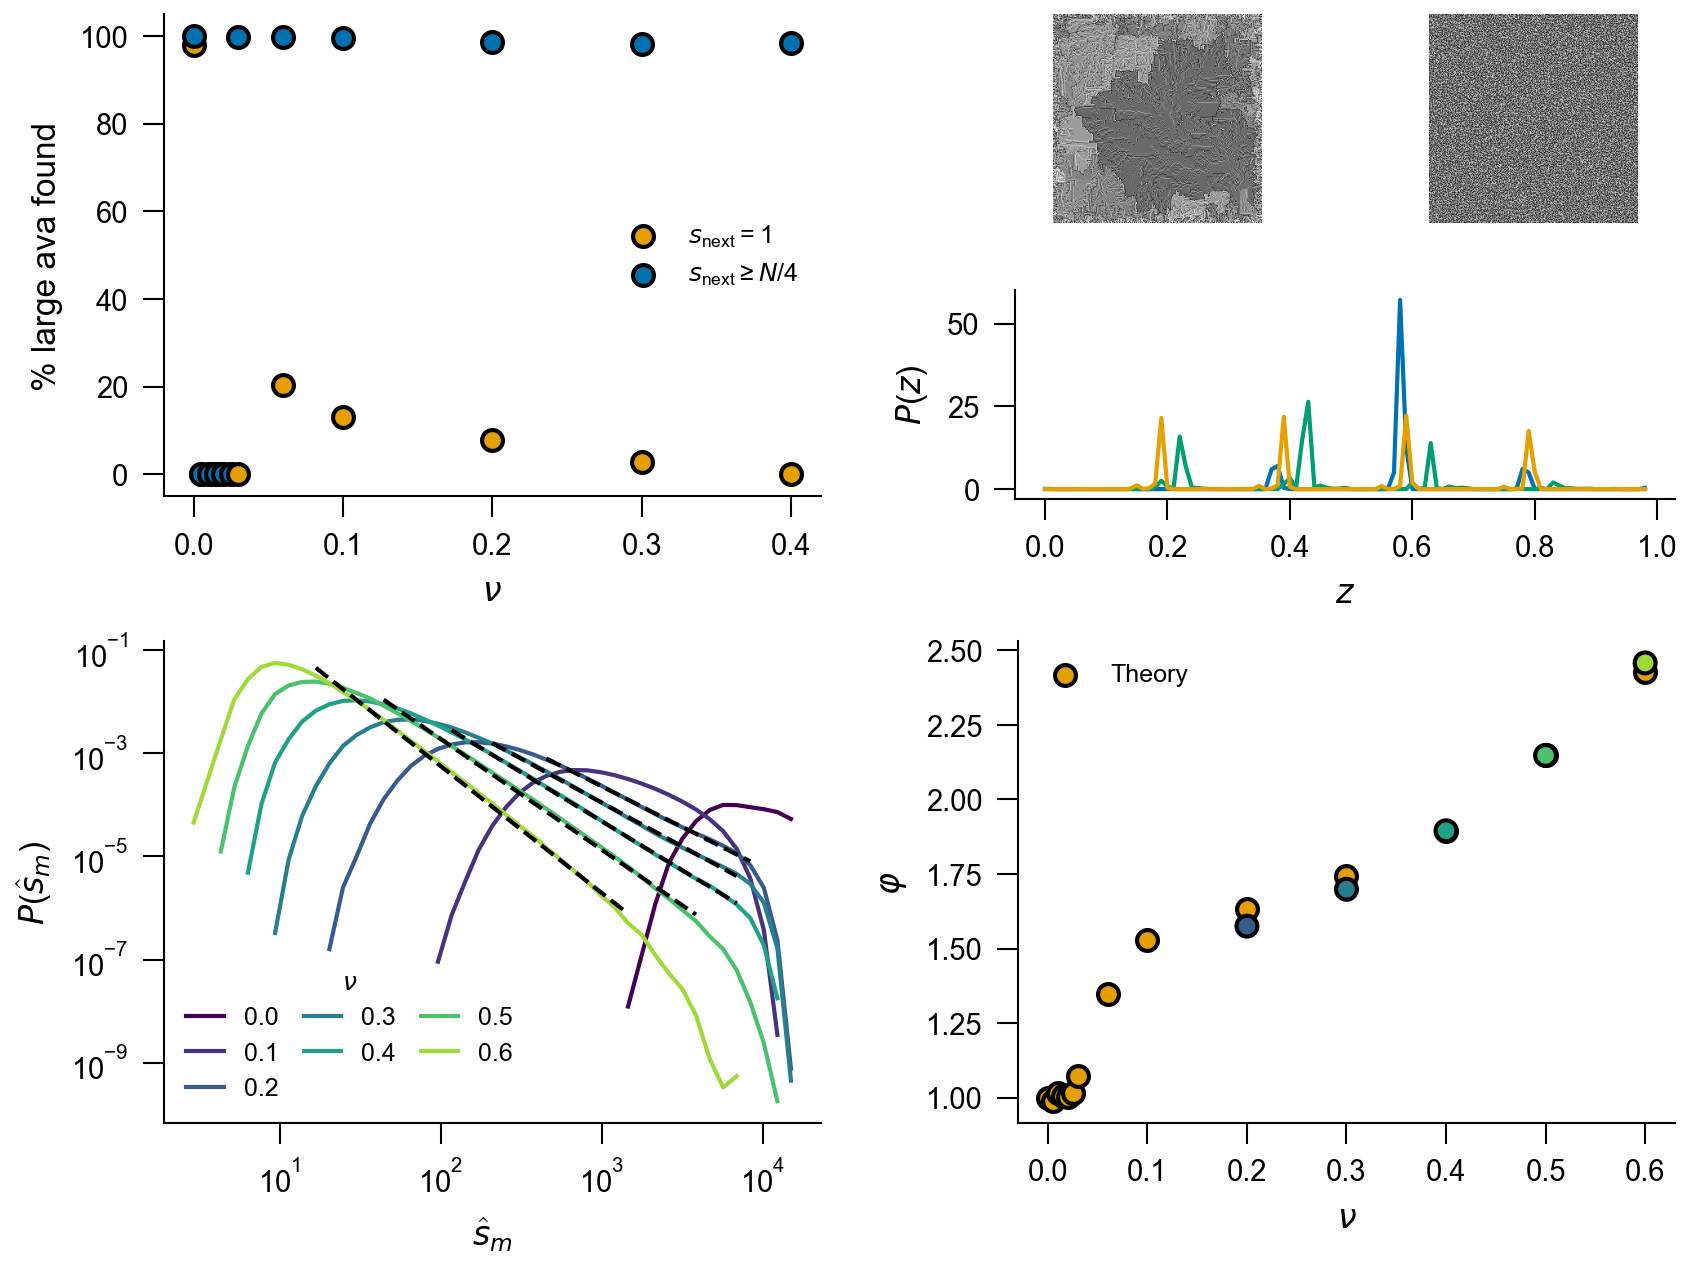

In [19]:
import warnings
from matplotlib.ticker import FixedLocator, NullLocator
from mpl_toolkits.axisartist.axislines import SubplotZero

warnings.resetwarnings()

Tfolderpath = ["/data1/DATA_Duplat/Brut/Memory_effects/Me60n{}".format(nb) for nb in range(1,13)]

Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 6e3, 1.2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 1e3, 400, 200, 100, 40, 15]
Ttau = [None]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

max_nbtry = 6554

warnings.filterwarnings("error")
with plt.style.context(spstyle.get_style('science-reviews')):
    fig = plt.figure(figsize=(6.5, 4.8))
    gs1 = gridspec.GridSpec(2, 2, width_ratios=[0.5,0.5], wspace = 0.3, hspace = 0.3)
    gs3 = gridspec.GridSpec(4, 4, width_ratios = [0.27, 0.27, 0.23, 0.23], height_ratios = [0.23, 0.23, 0.27, 0.27], wspace = 0.3, hspace = 0.3)
    
    
    ax1 = fig.add_subplot(gs1[0, 0])
    ax2 = fig.add_subplot(gs1[1, -1])
    ax22 = fig.add_subplot(gs1[1, 0])
    ax31 = fig.add_subplot(gs3[0, 2])
    ax32 = fig.add_subplot(gs3[0, 3])
    ax33 = fig.add_subplot(gs3[1, 2:])
    
    ######NTRY######
    for i, folder in enumerate(Tfolderpath):
        nu = read_parameters(folder)[2]
        small_data = np.loadtxt("{}/random_small.txt".format(folder))
        try:
            large_data = np.loadtxt("{}/random_large.txt".format(folder))
        except UserWarning:
            large_data = np.ones((1,6))
            large_data[0,-1] = max_nbtry
        
        mask_small = small_data[:, -1] != max_nbtry
        mask_large = large_data[:, -1] != max_nbtry
        
        f_small = small_data[mask_small]
        f_large = large_data[mask_large]
        
        p_small = len(f_small)/len(small_data)
        p_large = len(f_large)/len(large_data)
        print(p_large)
        if i == 0:
            ax1.scatter(nu,  p_small*100, c = color_list[2], label = r"$s_\mathrm{next} = 1$" )
            ax1.scatter(nu,  p_large*100, c = color_list[0], label = r"$s_\mathrm{next} \geq N/4$")
        else:
            ax1.scatter(nu,  p_small*100, c = color_list[2])
            ax1.scatter(nu,  p_large*100, c = color_list[0])
    
    ######P(smax)######
    for j, n in enumerate(Tnu):
        ax22.plot(Tbin_s1[j], Thisto_s1[j], c = Tcolor[j], label = n)
        if j not in [0, 1]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
            """ tau = popt[1]
            Tperr[j] = np.sqrt(np.diag(pcov))[1] """
            Ttau[j] = popt[1]
            yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
            ax22.plot(Tbin_s1[j][start:stop], yfit, ls = '--', c ='k', lw =1)

    ######Pl cut-off######
    a = 1
    b = 1.2
    c = 32
    d = 2
    
    c2 = 8
    d2 = 2
    
    c3 = 2
    d3 = 2
    
    c4 = 2000
    d4 = 2
    
    x = np.arange(1,10000, 0.1, dtype= float)
    y = powercutoff_fit(x, a,b,c,d)
    y2 = powercutoff_fit(x, a,b,c2,d2)
    y3 = powercutoff_fit(x, a,b,c3,d3)
    y4 = powercutoff_fit(x, a,b,c4,d4)

    x_crit = np.arange(1,10000, 1, dtype= float)
    y_crit = powerlaw(x_crit, a, -b) 
    
    b5 = 2
    c5 = 7000
    d5 = 10
    y5 = powercutoff_fit(x, a,b5,c5,d5)
    ax33.set_xlabel(r"$z$")
    ax33.set_ylabel(r"$P(z)$")
    
    ######Snapshots and distrib######
    sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
    sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd8n7/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
    
    nbins = 100
    sys1_filtered = sys1[100:210,90:200]
    sys1_filtered2 = sys1[20:75,20:75]
    
    histo1, bins1 = np.histogram(sys1_filtered, bins = np.arange(0,1,1/nbins), density=True)
    histo2, bins2 = np.histogram(sys1_filtered2, bins = np.arange(0,1,1/nbins), density=True)
    histo3, bins3 = np.histogram(sys2, bins = np.arange(0,1,1/nbins), density=True)
    
    
    ax31.imshow(sys1, cmap = "binary", vmin = 0, vmax = 1)
    ax32.imshow(sys2, cmap = "binary", vmin = 0, vmax = 1)
    ax33.plot(bins1[:-1], histo1, c = color_list[0])
    ax33.plot(bins2[:-1], histo2, c = color_list[1])
    ax33.plot(bins3[:-1], histo3, c = color_list[2])
    
    
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel('% large ava found')
    ax1.legend()
    
    ax2.scatter(Tnu_th, 2-(-Tgamma_th), c = color_list[2], label = r'Theory')
    ax2.scatter(Tnu[2:], -np.array(Ttau)[2:], c = Tcolor[2:])
    ax2.set_ylabel(r"$\varphi$")
    ax2.set_xlabel(r"$\nu$")
    ax2.legend()
    
    ax22.set_xlabel(r"$\hat s_m$")
    ax22.set_ylabel(r"$P(\hat s_m$)")
    ax22.set_xscale('log')
    ax22.set_yscale('log')
    ax22.legend(title = r"$\nu$", loc = "lower left", ncol = 3, columnspacing=1.0, handlelength=1.5)
    
    ax31.set_axis_off()
    ax32.set_axis_off()
    ax33.set_xlabel(r"$z$")
    ax33.set_ylabel(r"$P(z)$")
    
    # fig.text(0.1, 0.885, "a", fontsize=7, fontweight="bold") 
    # fig.text(0.37, 0.885, "b", fontsize=7, fontweight="bold") 
    # fig.text(0.65, 0.885, "c", fontsize=7, fontweight="bold") 
    # fig.text(0.1, 0.46, "d", fontsize=7, fontweight="bold") 
    # fig.text(0.1, 0.28, "e", fontsize=7, fontweight="bold") 
    # fig.text(0.38, 0.46, "f", fontsize=7, fontweight="bold") 
    # fig.text(0.65, 0.46, "g", fontsize=7, fontweight="bold") 
    # fig.text(0.5, 0.76, r"$\tau _c$")
    # fig.text(0.77, 0.76, r"$\tau _c$")
    # fig.text(0.77, 0.68, r"$\tau$")
    
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax22.patch.set_alpha(0.0)
    ax33.patch.set_alpha(0.0)
    fig.savefig('Fig5_prev_science.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show() 
    
warnings.resetwarnings()

#   FSS

In [15]:
data = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_3.npz")
print(data.files)

['nu', 's_64_nu0', 'p_s_64_nu0', 's_64_nu03', 'p_s_64_nu03', 's_128_nu0', 'p_s_128_nu0', 's_128_nu03', 'p_s_128_nu03', 's_256_nu0', 'p_s_256_nu0', 's_256_nu03', 'p_s_256_nu03', 's_512_nu0', 'p_s_512_nu0', 's_512_nu03', 'p_s_512_nu03', 'N', 'smax_nu0', 'smax_nu03', 'rescaled_s_64_nu0', 'rescaled_p_s_64_nu0', 'rescaled_s_64_nu03', 'rescaled_p_s_64_nu03', 'rescaled_s_128_nu0', 'rescaled_p_s_128_nu0', 'rescaled_s_128_nu03', 'rescaled_p_s_128_nu03', 'rescaled_s_256_nu0', 'rescaled_p_s_256_nu0', 'rescaled_s_256_nu03', 'rescaled_p_s_256_nu03']


/tmp/ipykernel_455414/223711299.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


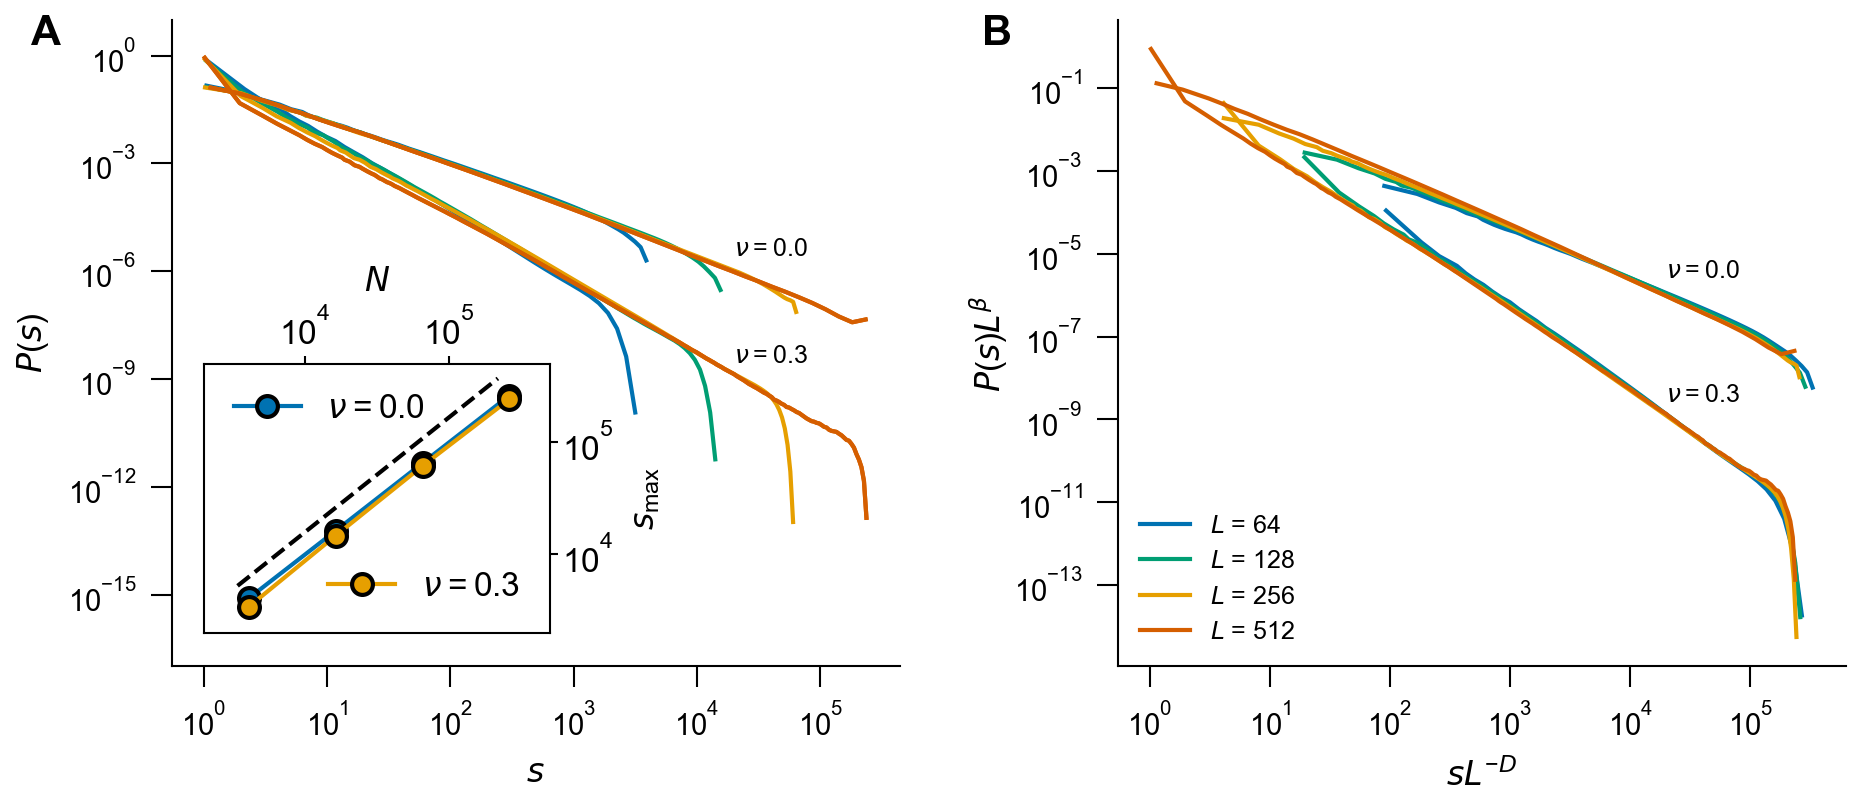

In [18]:
TL = np.array([64,128,256,512])
TN = TL**2
Tnu = data["nu"]
NCURVES = len(TL)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


with plt.style.context(spstyle.get_style('science-reviews')):
 
    fig, (ax, ax3) = plt.subplots(1,2, figsize = (7.2,2.8))
    fig.subplots_adjust(wspace = 0.3)
    
   
    for i, L in enumerate(TL):
        for j, nu in enumerate(Tnu):
            nu_str = str(nu).replace('.', '')
            if j == 0: nu_str = "0"
            
            s = data[f"s_{L}_nu{nu_str}"]
            ps = data[f"p_s_{L}_nu{nu_str}"]
            ax.plot(s, ps, c = color_list[i])
            if L == 512:
                ax.plot(s, ps, c = color_list[i])
                if j == 0:
                    ax3.plot(s, ps, c = color_list[i], label = r"$L$ = {}".format(L))
                else:
                    ax3.plot(s, ps, c = color_list[i])
            else:
                r_s = data[f"rescaled_s_{L}_nu{nu_str}"]
                r_ps = data[f"rescaled_p_s_{L}_nu{nu_str}"]
                if j == 0:
                    ax3.plot(r_s, r_ps, c = color_list[i], label = r"$L$ = {}".format(L))
                else:
                    ax3.plot(r_s, r_ps, c = color_list[i])
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s)$')
    ax.set_ylim(10**-17, 10)
    ax.set_xticks([1,10,100,1000,10000,100000])
    ax.set_yticks([1e0, 1e-3, 1e-6, 1e-9, 1e-12, 1e-15])
    # ax.legend(handles=[leg1, leg2, leg3, leg4], ncols = 2, loc = "upper right")
    
    
    # ax2 = fig.add_axes([0.18, 0.205, 0.15, 0.30])
    ax2 = fig.add_axes([0.14, 0.15, 0.16, 0.32])
    
    line1, = ax2.plot(data["N"], data["smax_nu0"], c = color_list[0], marker = 'o', label=r"$\nu = 0.0$")
    line2, = ax2.plot(data["N"], data["smax_nu03"], c = color_list[2], marker = 'o', label=r"$\nu = 0.3$")
    
    popt2, _ = curve_fit(powerlaw2, np.log(data["N"]), np.log(data["smax_nu03"]))
    a2, b2 = popt2
    y_fit2 = np.exp(powerlaw2(np.log(data["N"]), a2, b2))
    ax2.plot(data["N"]/1.2 , 1.5*y_fit2, ls = '--', c ='k')
    
    ax2.set_xlabel(r'$N$')
    ax2.set_ylabel(r'$s_\mathrm{max}$')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.tick_params(labelsize = 8, length = 2, pad = 1) 
    ax2.tick_params(length = 0, which = 'minor')
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    # ax2.xaxis.labelpad = 4
    ax2.xaxis.tick_top()
    ax2.xaxis.set_label_position('top')
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position('right')
    ax2.set_xlim(2e3, 5e5)
    ax2.set_ylim(2e3, 5e5)
    ax2.patch.set_alpha(0.0)
    
    legbis1 = ax2.legend(handles=[line1], fontsize=8, loc="upper left")
    legbis2 = ax2.legend(handles=[line2], fontsize=8, loc="lower right")
    ax2.add_artist(legbis1)
    # ax2.legend(fontsize = 8, loc = "lower right")

    
    #######RESCALED

    
    
    ax3.set_xlabel(r'$sL^{-D}$')
    ax3.set_ylabel(r'$P(s)L^{\beta}$')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.yaxis.labelpad = 1
    ax3.set_xticks([10**1, 10**5])
    ax3.patch.set_alpha(0.0)
    ax3.set_xticks([1,10,100,1000,10000,100000])
    ax.text(2.e4, 2e-6, r"$\nu = 0.0$", color="k", va="bottom")
    ax.text(2.e4, 2e-9, r"$\nu = 0.3$", color="k", va="bottom")
    
    ax3.text(2.e4, 2e-6, r"$\nu = 0.0$", color="k", va="bottom")
    ax3.text(2.e4, 2e-9, r"$\nu = 0.3$", color="k", va="bottom")
    
    ax3.legend(loc = "lower left")
    
    fig.text(0.06, 0.85, "A", fontsize=10, fontweight="bold") 
    fig.text(0.5, 0.85, "B", fontsize=10, fontweight="bold")
    
    
    
    
    fig.patch.set_alpha(0.0)
    plt.savefig('Ext_data_fig2_science.pdf', bbox_inches='tight', dpi = 300)    
    plt.show()

    

#   Figshare

##  Figure 2

In [28]:
data = np.load("Figure2.npz", allow_pickle=True)

Tvar = data["Tvar"]
Ttau_s = data["Ttau_s"]
Tbins_s = data["Tbins_s"]
Thisto_s = data["Thisto_s"]
Txfit_s = data["Txfit_s"]
Tyfit_s = data["Tyfit_s"]
Tnonzero_s= data["Tnonzero_s"] 
Tmean_s= data["Tmean_s"]
Tmean_t= data["Tmean_t"]
Tmean_diff= data["Tmean_diff"]

In [29]:
label =[]
[label.extend(["s", "P(s) (nu = {})".format(nu), "s", "power-law fit (nu = {})".format(nu)]) for nu in Tvar]
label = pd.Series(label)
label.astype("category")
label.astype(str)

0                              s
1                P(s) (nu = 0.0)
2                              s
3       power-law fit (nu = 0.0)
4                              s
5              P(s) (nu = 0.005)
6                              s
7     power-law fit (nu = 0.005)
8                              s
9               P(s) (nu = 0.01)
10                             s
11     power-law fit (nu = 0.01)
12                             s
13             P(s) (nu = 0.015)
14                             s
15    power-law fit (nu = 0.015)
16                             s
17              P(s) (nu = 0.02)
18                             s
19     power-law fit (nu = 0.02)
20                             s
21             P(s) (nu = 0.025)
22                             s
23    power-law fit (nu = 0.025)
24                             s
25              P(s) (nu = 0.03)
26                             s
27     power-law fit (nu = 0.03)
28                             s
29              P(s) (nu = 0.06)
30        

In [30]:
dfa = pd.DataFrame()
for i in range(len(Tvar)):
    df1 = pd.DataFrame([Tbins_s[i], Thisto_s[i]])
    df2 = pd.DataFrame([Txfit_s[i], Tyfit_s[i]])
    
    dfa = pd.concat([dfa, df1, df2])
dfa = dfa.T
dfa.columns = label

In [31]:
labelb = ["nu", "tau"]
dfb = pd.DataFrame([Tvar, -Ttau_s]).T
dfb.columns = labelb


In [32]:
labelc = ["nu", "s_max"]
dfc = pd.DataFrame([Tvar, Tnonzero_s]).T
dfc.columns = labelc

In [33]:
labeld = ["nu", "<s>^(1/2)", "nu", "<delta z>"]
dfd = pd.DataFrame([Tvar, Tmean_s**(1/2), Tvar, Tmean_diff]).T
dfd.columns = labeld

In [34]:
labele = ["nu", "<ntop>*nu", "nu", "<delta z><s>^1/2"]
dfe= pd.DataFrame([Tvar, Tmean_t * Tvar, Tvar, Tmean_diff*Tmean_s**(1/2)]).T
dfe.columns = labele

In [35]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Science/Figure2.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc.to_excel(writer, sheet_name="c", index=False)
    dfd.to_excel(writer, sheet_name="d", index=False)
    dfe.to_excel(writer, sheet_name="e", index=False)

##  Figure 3

In [3]:
data3_5 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_5.npz")
data3_4 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_4.npz")
data3_7 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_7.npz")

In [4]:
Tnu = data3_5["nu"]

Tp_t = [None] * len(Tnu)
Tt = [None] * len(Tnu)
Txfit = [None] * len(Tnu)
Tyfit = [None] * len(Tnu)



for i, nu in enumerate(Tnu):
    nu_str = str(nu).replace('.', '_')
    if i == 0: nu_str = "0"

    Tp_t[i] = data3_5[f"p_t_nu{nu_str}"]
    Tt[i] = data3_5[f"t_nu{nu_str}"]
    Txfit[i] = data3_5[f"xfit_nu{nu_str}"]
    Tyfit[i] = data3_5[f"yfit_nu{nu_str}"]
    

Tgamma = data3_5["gamma"]

L = data3_4["L"]
sys_snap = data3_4["system"].reshape(L,L)
last_epi = data3_4["last_epicenter_x_y"]
next_epi = data3_4["next_epicenter_x_y"]
sideview_before = data3_4["side_view_before"]
sideview_after = data3_4["side_view_after"]

snap_cons = data3_7["system1"].reshape(L,L)
epi_cons =  np.unravel_index(data3_7["epicenter1"], (L,L))
snap_diss = data3_7["system3"].reshape(L,L)
epi_diss = np.unravel_index(data3_7["epicenter3"],(L,L))

In [ ]:
with plt.style.context(spstyle.get_style('science-reviews')):
    fig = plt.figure(figsize=(8.2, 4.8))
    
    gs1 = gridspec.GridSpec(2, 3, wspace = 0.3, hspace = 0.3)
    gs2 = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.1)
    gs3 = gridspec.GridSpec(2, 3, width_ratios=[0.27,0.4,0.33], height_ratios=[0.52,0.48], wspace = 0.43, hspace = 0.2)
    
    ax1 = fig.add_subplot(gs1[0, 0])
    ax2 = fig.add_subplot(gs1[1, 0])
    ax3 = fig.add_subplot(gs1[1, 1])
    ax4 = fig.add_subplot(gs3[0, 1])
    ax5 = fig.add_subplot(gs2[0, 2])
    ax6 = fig.add_subplot(gs2[1, 2])
    
    ax32 = fig.add_axes([0.2, 0.2, 0.08, 0.12])
    
    for i in range(len(Tnu)):
        ax1.plot(Tt[i],Tp_t[i], c = colors_pt[i])
        ax1.plot(Txfit[i],Tyfit[i], c ='k', ls = '--')
    
    im = ax4.imshow(sys_snap, cmap = 'gray', vmin = 0, vmax = 1)
    ax4.axhline(next_epi[1], c = color_list[2], alpha = 0.5)
    ax4.scatter(last_epi[0], last_epi[1], color = 'r', s = 7, zorder = 5)
    ax4.scatter(next_epi[0], next_epi[1], color = 'g', s = 7, zorder = 5)

    
    ax5.imshow(snap_cons, cmap ='binary', vmin = 0, vmax = 1)
    ax5.scatter(epi_cons[1], epi_cons[0], color = colors, s = 0.5, alpha = 0.5)
    
    ax2.scatter(Tnu, -Tgamma, c = colors_pt, s = 20, zorder = 10)
    ax2.plot(Tnu, -Tgamma, ls = '-', c ='k')
    ax32.scatter(Tnu, -Tgamma, c = colors_pt, s = 20, zorder = 10)
    ax32.plot(Tnu, -Tgamma, ls = '-', c ='k')
    
    ax32.tick_params(labelsize = 8, length = 2, pad = 1)
    ax3.plot(sideview_before, c = color_list[0], label = "Before")
    ax3.plot(sideview_after, c = color_list[2], label = "After")
    ax3.scatter(next_epi[0], sideview_after[next_epi[0]], color = 'g', s = 5, zorder = 2, label = "Next epicenter")
    
    ax6.imshow(snap_diss, cmap ='binary', vmin = 0, vmax = 1)
    ax6.scatter(epi_diss[1], epi_diss[0], color = colors, s = 0.5, alpha = 0.1)
    
   

In [7]:
labela = []
[labela.extend(["T/<T> (nu = {})".format(nu), "P(t)<T> (nu = {})".format(nu), "xfit (nu = {})".format(nu), "yfit (nu = {})".format(nu)]) for nu in Tnu]

dfa = pd.DataFrame()
for i in range(len(Tnu)):
    df1 = pd.DataFrame([Tt[i], Tp_t[i], Txfit[i], Tyfit[i]])
    dfa = pd.concat([dfa, df1])
dfa = dfa.T
dfa.columns = labela

In [8]:
labelb = ["nu", "gamma"]
dfb = pd.DataFrame([Tnu, -Tgamma]).T
dfb.columns = labelb

In [16]:
labelc = ["L", "System", "last_epicenter_x_y", "next_epicenter_x_y"]
dfc = pd.DataFrame([[L], data3_4["system"].flatten(), last_epi, next_epi]).T
dfc.columns = labelc

In [11]:
labeld = ["side_view_before", "side_view_after", "next_epicenter_x_y"]
dfd = pd.DataFrame([data3_4["side_view_before"], data3_4["side_view_after"], data3_4["next_epicenter_x_y"]]).T
dfd.columns = labeld

In [26]:
labele = ["L", "conservative system", "epicenters",]
dfe = pd.DataFrame([[L], data3_7["system1"], np.reshape(data3_7["epicenter1"], len(data3_7["epicenter1"]))]).T
dfe.columns = labele

In [24]:
labelf = ["L", "dissipative system","epicenters"]
dff = pd.DataFrame([[L], data3_7["system3"], np.reshape(data3_7["epicenter3"], len(data3_7["epicenter3"]))]).T
dff.columns = labelf

In [27]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Science/Figure3.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc.to_excel(writer, sheet_name="c", index=False)
    dfd.to_excel(writer, sheet_name="d", index=False)
    dfe.to_excel(writer, sheet_name="e", index=False)
    dff.to_excel(writer, sheet_name="f", index=False)
    

##  Figure 4

In [36]:
def count_lines_gz_safe(filename, csize = 1000):
    count = 0
    chunk_size = csize 
    try:
        with gzip.open(filename, 'rb') as f:
            leftover = b''
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                lines = (leftover + chunk).split(b'\n')
                leftover = lines.pop()  # dernière ligne peut être tronquée
                count += len(lines)
            if leftover:
                count += 1  # compte la dernière ligne même si tronquée
    except EOFError:
        # fichier tronqué, on arrête là et on retourne le compte
        pass
    return count

def process_parallel_load(foldernb, nb = [1,2,3,4,5,6,7,8,9], chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    # logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    # histo_s = np.zeros(len(logbins_s)-1)
    bins_s = np.arange(0, L**2)
    histo_s = np.zeros(len(bins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    for i in nb:
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                # histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
                histo_s += np.histogram(chunk.iloc[:, 0], bins = bins_s)[0]
                histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
                
                nblines += len(chunk)
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s= int(float(line.strip().split()[cols[0]]))

                    # id = np.searchsorted(logbins_s, s, side='right') -1
                    # histo_s[id] += 1
                    histo_s[s] +=1
                    
                    id = np.searchsorted(logbins_a, 1/s, side='left') - 1
                    histo_a[id] += 1
                    
                    if i >= limdata:
                        break
        
    logbins_s, loghisto_s = new_logbins(histo_s, nbins)
    
    # log_histo, log_bins = loghisto(histo_s)
    # norm_histo_s = loghisto_s/((np.diff(logbins_s)) * np.sum(loghisto_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    # return logbins_s, norm_histo_s, logbins_a, norm_histo_a
    return logbins_s, loghisto_s, logbins_a, norm_histo_a

def floor_sig(x, n=1): #Pour récupére le floor de la valeur
    p = int(np.floor(np.log10(abs(x))))
    fact = 10 ** (p - n + 1)
    return int(np.floor(x / fact) * fact)

def count_lines(Tfolder_nb, nbfolder):
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        min = 1e10
        print(nb)
        for i in range(1,nbfolder+1):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = count_lines_gz_safe(file)
            print (nbl)
            if nbl < min:
                min = nbl
        print(min)
        
def full_analysis(Tfolder_nb, nbins = 50, cols = [12], nbfolder = [1,2,3,4,5,6,7,8,9]): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in nbfolder:
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        print(min)
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a
    
def gamma_th():

    fnb = np.arange(1,15)
    folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
    """ folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
    Tvar = [read_parameters(folder)[2] for folder in folderpath]

    results = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)
    Thisto_s, Tbins_s, _, _, _ = zip(*results)

    Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
    Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
    _, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)
    
    gamma = (-Ttau_s) - (-Ttau_s[0]) - 1
    
    return Tvar, gamma
    

def log_exppowlaw(x, a, b, c):
    return np.log(a)-b*np.log(x)-x/c


In [43]:
Tfolder_nb = [77,78,79,80,81,83, 82]
Tbin_s1, Thisto_s1, Tbin_a1, Thisto_a1 = full_analysis(Tfolder_nb, nbfolder = [2,3,4,5,6,7,8,9], nbins = 50, cols =[12])
Tnu_th, Tgamma_th = gamma_th()

36000
360000
390000
380000
360000
290000
340000
0.96545763582405
0.9971726928826957
0.9940950079772213
0.9970879131270517
0.9967105205796035
0.9906659255469019
0.9877020531728582
0.9272213838997168
0.9122521887346848
0.9705872766834267
0.9174095398449836
0.9057453446744788
0.8991641398725068
0.8933054895985362


In [44]:
import warnings
from matplotlib.ticker import FixedLocator, NullLocator
from mpl_toolkits.axisartist.axislines import SubplotZero

warnings.resetwarnings()

Tfolderpath = ["/data1/DATA_Duplat/Brut/Memory_effects/Me60n{}".format(nb) for nb in range(1,13)]

Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 6e3, 1.2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 1e3, 400, 200, 100, 40, 15]
Ttau = [None]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

max_nbtry = 6554

warnings.filterwarnings("error")
    
Tp_small = []
Tp_large = []
Tvar_ntry = []
######NTRY######
for i, folder in enumerate(Tfolderpath):
    nu = read_parameters(folder)[2]
    small_data = np.loadtxt("{}/random_small.txt".format(folder))
    try:
        # nbline = 0
        # with open(f"{folder}/random_large.txt") as f:
        #     for line in f :
        #         nbline +=1
                
        large_data = np.loadtxt("{}/random_large.txt".format(folder))
    except UserWarning:
        large_data = np.ones((1,6))
        large_data[0,-1] = max_nbtry
    
    mask_small = small_data[:, -1] != max_nbtry
    mask_large = large_data[:, -1] != max_nbtry
    
    f_small = small_data[mask_small]
    f_large = large_data[mask_large]
    
    p_small = len(f_small)/len(small_data)
    p_large = len(f_large)/len(large_data)
    print(p_large)
    Tp_small.append(p_small*100)
    Tp_large.append(p_large*100)
    Tvar_ntry.append(nu)

######P(smax)######
Txfit = []
Tyfit = []
for j, n in enumerate(Tnu):
    if j in [0,1]:
        Txfit.append(0)
        Tyfit.append(0)
    if j not in [0]:
        start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
        stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
        popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
        Ttau[j] = popt[1]
        yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
        xfit = Tbin_s1[j][start:stop]
        Txfit.append(xfit)
        Tyfit.append(yfit)


L1 = 256
L2 = 256
######Snapshots and distrib######
sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd8n7/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T

nbins = 100
sys1_filtered = sys1[100:210,90:200]
sys1_filtered2 = sys1[20:75,20:75]

histo1, bins1 = np.histogram(sys1_filtered, bins = np.arange(0,1,1/nbins), density=True)
histo2, bins2 = np.histogram(sys1_filtered2, bins = np.arange(0,1,1/nbins), density=True)
histo3, bins3 = np.histogram(sys2, bins = np.arange(0,1,1/nbins), density=True)



0.9996666666666667
0.0
0.0
0.0
0.0
0.0
0.9988888888888889
0.998
0.996
0.987
0.9813333333333333
0.9836842105263158


/tmp/ipykernel_1450618/1106848745.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


In [45]:
labela = ["nu", "%large ava found (s_next = 1)", "nu", "%large ava found (s_next = N/4)"]
dfa = pd.DataFrame([Tvar_ntry, Tp_small, Tvar_ntry, Tp_large]).T
dfa.columns = labela

In [53]:
labelb = ["z", "P(z) (blue)", "z", "P(z) (gree)", "z", "P(z) (orange)"]
dfb = pd.DataFrame([bins1, histo1, bins2, histo2, bins3, histo3]).T
dfb.columns = labelb

labelb2 = ["L", "system_left", "system_right"]
dfb2 = pd.DataFrame([[L1], sys1.flatten(), sys2.flatten()]).T
dfb2.columns = labelb2

In [50]:
labelc =[]
[labelc.extend(["s_c", "P(s_c) (nu = {})".format(nu), "s_c", "power-law fit (nu = {})".format(nu)]) for nu in Tnu]


dfc = pd.DataFrame()
for j, n in enumerate(Tnu):
    df1 = pd.DataFrame([Tbin_s1[j], Thisto_s1[j]])
    df2 = pd.DataFrame([Txfit[j], Tyfit[j]])
    dfc = pd.concat([dfc, df1, df2])
dfc = dfc.T
dfc.columns = labelc

In [51]:
labeld = ["nu", "phi (theory)", "nu", "phi (simulation)"]
dfd = pd.DataFrame([Tnu_th, 2-(-Tgamma_th), Tnu[1:], -np.array(Ttau)[1:]]).T
dfd.columns = labeld

In [54]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Science/Figure4.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfb2.to_excel(writer, sheet_name="b_snapshots", index=False, header = False)
    dfc.to_excel(writer, sheet_name="c", index=False)
    dfd.to_excel(writer, sheet_name="d", index=False)

##  Ext Fig 1 

In [55]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu5n{}".format(nb) for nb in [1,11]]
Tnu64 = [read_parameters(folder)[2] for folder in Tfolderpath]

results64 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s64, Tbins_s64, Tnonzero_s64, _, _ = zip(*results64)

In [56]:
Tfolderpath = [f'/data1/DATA_Duplat/Brut/Cut_off_size/Cu4n{nb}' for nb in [1,11]]
Tnu128 = [read_parameters(folder)[2] for folder in Tfolderpath]

results128 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s128, Tbins_s128, Tnonzero_s128, _, _ = zip(*results128)

In [57]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}".format(nb) for nb in [1,11]]
Tnu256 = [read_parameters(folder)[2] for folder in Tfolderpath]

results256 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s256, Tbins_s256,  Tnonzero_s256, _, _ = zip(*results256)

In [58]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu6n1"] + ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu2n{}".format(nb) for nb in [2]]
Tnu512 = [read_parameters(folder)[2] for folder in Tfolderpath]
Tnbins = [50,0,0]

results512 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder), nbins) for (folder, nbins) in zip(Tfolderpath, Tnbins))
Thisto_s512, Tbins_s512, Tnonzero_s512, _, _ = zip(*results512)

In [59]:
labela = []
[labela.extend(["s","P(s) (L={}, nu = {})".format(i,j)]) for i in [64,128,256,512] for j in [0.0, 0.3] ]
dfa = pd.DataFrame()

for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
    
dfa = dfa.T
dfa.columns = labela


S_cut_off_min = np.array([Tnonzero_s64[0], Tnonzero_s128[0], Tnonzero_s256[0], Tnonzero_s512[0]])
S_cut_off_min2 = np.array([Tnonzero_s64[1], Tnonzero_s128[1], Tnonzero_s256[1], Tnonzero_s512[1]])
L = np.array([64, 128, 256, 512])
LL = L*L

labela_insert = ["N", "s_max(nu=0.0)", "N", "s_max(nu=0.3)"]
dfa_insert = pd.DataFrame([LL,S_cut_off_min, LL, S_cut_off_min2])
dfa_insert = dfa_insert.T
dfa_insert.columns = labela_insert

########RESCALED
labelb = []
[labelb.extend(["sL^(-D)","P(s)L^beta (L={}, nu = {})".format(i,j)])for i in [64,128,256,512] for j in [0.0, 0.3] ]
dfb = pd.DataFrame()

alpha = 2.2
beta = np.array([2.8, 4.2])

xscale = (64**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
yscale = (64**beta)*(1/(512**beta))
for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
    bins = bins * xscale
    histo = histo * yscale[i]
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])

xscale = (128**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
yscale = (128**beta)*(1/(512**beta))
for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
    bins = bins * xscale
    histo = histo * yscale[i]
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])

xscale = (256**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
yscale = (256**beta)*(1/(512**beta))
for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
    bins = bins * xscale
    histo = histo * yscale[i]
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])


for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])

dfb = dfb.T
dfb.columns = labelb


In [60]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Science/FigureS1.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfa_insert.to_excel(writer, sheet_name="a_insert", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)

##  Ext Fig 2

In [61]:
fnb = np.arange(1,5)
folderpath = [f'/data1/DATA_Duplat/Brut/Rdtopple/Rd3n{nb}' for nb in fnb]
folderpath = np.array(['/data1/DATA_Duplat/Brut/PDF/PD5n1'] + folderpath)
folderpath = np.insert(folderpath, 2, ['/data1/DATA_Duplat/Brut/Rdtopple/Rd5n1', '/data1/DATA_Duplat/Brut/Rdtopple/Rd4n1'])
Tvar_rt = [read_parameters(folder)[2] for folder in folderpath]
Tvar_rt[4] = 0.06

In [62]:
result = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in folderpath)
Thisto_rt, Tbins_rt, nmax_rt, mean_rt, nbins_rt = zip(*result)

In [63]:
sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd3n1/Snapshots/nav100000000_outputB.txt", comments='#')
sys3 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd3n3/Snapshots/nav100000000000_outputB.txt", comments='#')

L = 256

In [66]:
labela = ["s", "P(s) (OFC)"]
[labela.extend(["s","P(s) (nu = {})".format(i)]) for i in [0,0.02,0.04,0.06,0.1]]
dfa = pd.DataFrame()

OFC = Thisto_rt[0]
for i, (histo, bins) in enumerate(zip(Thisto_rt[:-1], Tbins_rt[:-1])):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
dfa = dfa.T
dfa.columns = labela     
    
        
labelb = ["L", "system(nu = 0.0)", "system(nu = 0.1)"]
dfb = pd.DataFrame([[L], sys1, sys3]).T
dfb.columns = labelb

In [67]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Science/FigureS2.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)